<a href="https://colab.research.google.com/github/yusuf-codes10/deep-learining-project/blob/main/dp_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1- Introduction + Set-up


In [1]:
# STEP 1 — Set Kaggle credentials (run this first)
import os
from getpass import getpass

os.environ['KAGGLE_USERNAME'] = input("Enter Kaggle username: ")
os.environ['KAGGLE_API_TOKEN'] = getpass("Enter Kaggle API key: ")

Enter Kaggle username: youcefcopy
Enter Kaggle API key: ··········


In [2]:
# STEP 2 — Install Kaggle (run once per session)
!pip install -q kaggle

In [3]:
# STEP 3 — Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:24<00:00, 102MB/s]



In [4]:
# STEP 4 — Unzip dataset
!unzip -q chest-xray-pneumonia.zip

# 2- EDA

In [5]:

# check the folder strucutre
import os

base_path = "chest_xray"

for split in ['train', 'val', 'test']:
    print(f"\n{split.upper()} FOLDER:")
    for label in os.listdir(os.path.join(base_path, split)):
        count = len(os.listdir(os.path.join(base_path, split, label)))
        print(f"  {label}: {count} images")


TRAIN FOLDER:
  NORMAL: 1341 images
  PNEUMONIA: 3875 images

VAL FOLDER:
  NORMAL: 8 images
  PNEUMONIA: 8 images

TEST FOLDER:
  NORMAL: 234 images
  PNEUMONIA: 390 images


**Note**
Dataset is already imnalanced, we have to shuffle and balance it...

## 2-2 Show sample images

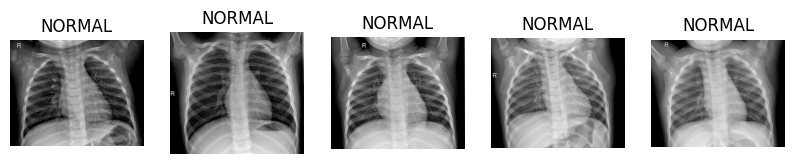

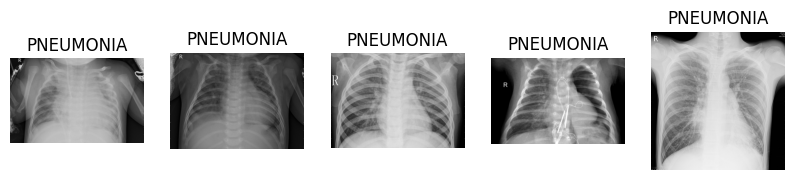

In [6]:
# show some sample images

import matplotlib.pyplot as plt
import cv2
import os

def show_samples(base_path, split, label):
    path = os.path.join(base_path, split, label)
    images = os.listdir(path)[:5]  # show 5 images

    plt.figure(figsize=(10, 3))

    for i, img_name in enumerate(images):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(1, 5, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(label)
        plt.axis('off')

    plt.show()

show_samples(base_path, 'train', 'NORMAL')
show_samples(base_path, 'train', 'PNEUMONIA')

**Note**  
Images are clear, mostly, and some of them do not have the same size

##  2-3 Check image sizes (CRUCIAL before model)

In [7]:
sizes = []

for label in ['NORMAL', 'PNEUMONIA']:
    path = os.path.join(base_path, 'train', label)

    for img_name in os.listdir(path)[:100]:  # sample 100
        img = cv2.imread(os.path.join(path, img_name))
        sizes.append(img.shape)

print(set(sizes))

{(1141, 1430, 3), (792, 1064, 3), (1303, 1928, 3), (1310, 1542, 3), (677, 1148, 3), (1079, 1416, 3), (712, 984, 3), (1160, 1454, 3), (728, 1240, 3), (1109, 1522, 3), (1013, 1284, 3), (948, 1352, 3), (1224, 1400, 3), (1071, 1454, 3), (950, 1264, 3), (1160, 1416, 3), (712, 1080, 3), (1544, 1704, 3), (1214, 1708, 3), (1441, 1790, 3), (1554, 1970, 3), (1024, 1396, 3), (1156, 1678, 3), (1078, 1368, 3), (1476, 1956, 3), (1304, 1624, 3), (952, 1232, 3), (1156, 1570, 3), (850, 1114, 3), (664, 968, 3), (1255, 1546, 3), (1357, 1886, 3), (1349, 1696, 3), (1032, 1400, 3), (1364, 1654, 3), (1552, 1880, 3), (672, 1000, 3), (762, 1284, 3), (885, 1268, 3), (1553, 1704, 3), (1534, 1712, 3), (1226, 1608, 3), (864, 1232, 3), (592, 992, 3), (1634, 1956, 3), (1245, 1670, 3), (640, 1008, 3), (1128, 1336, 3), (712, 1136, 3), (1510, 1596, 3), (1110, 1342, 3), (720, 1000, 3), (936, 1304, 3), (1527, 1906, 3), (844, 1164, 3), (1232, 1456, 3), (1893, 2292, 3), (1662, 1774, 3), (1661, 1910, 3), (731, 1134, 3), (15

**Note** as we can clrearly see now, they absolutely DO NOT have a uniform size, so we have to consifer this

**Note** Skipping Pixel Distrubution due to not enough RAM

# New section (Cleaner)

In [8]:
# ── Load all training images manually at 64x64 ──────────────────────────────
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator

def load_images_from_folder(folder, label, target_size=(64, 64)):
    images, labels = [], []
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            img = load_img(fpath, target_size=target_size)
            images.append(img_to_array(img) / 255.0)
            labels.append(label)
        except:
            pass
    return images, labels

normal_imgs, normal_labels       = load_images_from_folder("chest_xray/train/NORMAL",    0)
pneumonia_imgs, pneumonia_labels = load_images_from_folder("chest_xray/train/PNEUMONIA", 1)

print(f"NORMAL:    {len(normal_imgs)}")
print(f"PNEUMONIA: {len(pneumonia_imgs)}")

NORMAL:    1341
PNEUMONIA: 3875


**Note** Data Imbalance

In [9]:
# ── Augment NORMAL only until it matches PNEUMONIA count ────────────────────
aug = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

normal_imgs_aug    = list(normal_imgs)
normal_labels_aug  = list(normal_labels)
target_count       = len(pneumonia_imgs)
normal_array       = np.array(normal_imgs)

while len(normal_imgs_aug) < target_count:
    idx       = np.random.randint(0, len(normal_imgs))
    src       = normal_array[idx].reshape(1, 64, 64, 3)
    augmented = next(aug.flow(src, batch_size=1))[0]
    normal_imgs_aug.append(augmented)
    normal_labels_aug.append(0)

print(f"NORMAL after oversampling: {len(normal_imgs_aug)}")
print(f"PNEUMONIA:                 {len(pneumonia_imgs)}")

NORMAL after oversampling: 3875
PNEUMONIA:                 3875


In [10]:
# ── Combine + shuffle ────────────────────────────────────────────────────────
X = np.array(normal_imgs_aug + pneumonia_imgs)
y = np.array(normal_labels_aug + pneumonia_labels)

idx  = np.random.permutation(len(X))
X, y = X[idx], y[idx]

print(f"Final dataset: {X.shape}")
print(f"NORMAL={sum(y==0)}, PNEUMONIA={sum(y==1)}")

Final dataset: (7750, 64, 64, 3)
NORMAL=3875, PNEUMONIA=3875


In [11]:
# ── Train/val split ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")

Train: (6200, 64, 64, 3) | Val: (1550, 64, 64, 3)


## ANN Model Fittin

In [12]:
# ANN Model — same balanced data as CNN v3
import tensorflow as tf
from tensorflow import keras

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[64, 64, 3]),

    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

In [14]:
history = model.fit(
    X_train, y_train,          # 🔥 same balanced data as CNN v3
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    # callbacks=[early_stop]
)

Epoch 1/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.7100 - loss: 0.6711 - val_accuracy: 0.9019 - val_loss: 0.2780
Epoch 2/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.8627 - loss: 0.3202 - val_accuracy: 0.8968 - val_loss: 0.2613
Epoch 3/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.8511 - loss: 0.3383 - val_accuracy: 0.9194 - val_loss: 0.2206
Epoch 4/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.8387 - loss: 0.3332 - val_accuracy: 0.9032 - val_loss: 0.2330
Epoch 5/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.8523 - loss: 0.3031 - val_accuracy: 0.9419 - val_loss: 0.1702
Epoch 6/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.8577 - loss: 0.3015 - val_accuracy: 0.8923 - val_loss: 0.2356
Epoch 7/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.8421 - loss: 0.3207 - val_accuracy: 0.9058 - val_loss: 0.2307
Epoch 8/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.8582 - loss: 0.2867 - v

# 4- Fitting and Training

## 1- Baseline model (ANN)

In [ ]:
# using keras
import tensorflow as tf
from tensorflow import keras

In [ ]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[64, 64, 3]),

    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dropout(0.2),    # randomly dropout 20%

    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dropout(0.2),    # randomly dropout 20%

    keras.layers.Dense(1, activation="sigmoid") # best for binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │     3,686,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,716,901 (14.18 MB)

 Trainable params: 3,716,901 (14.18 MB)

 Non-trainable params: 0 (0.00 B)

**NOTES**
- lots of parameters, we expect overfitting of course.
- we might need to do dropping and l1/l2

In [ ]:
# let us try to train the model without any reglization, well excpet droput
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])


**NOTES**
- binary_crossentropy as the loss function, the name is self explanotary
- adam is really good for binary classification
- We might wanna adjust the learning rate


In [ ]:
# fitting the model
history = model.fit(train_generator, validation_data=val_generator, epochs=30, class_weight=class_weights_dict)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 61s 447ms/step - accuracy: 0.7601 - loss: 0.6354 - val_accuracy: 0.8955 - val_loss: 0.2558
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 56s 431ms/step - accuracy: 0.8807 - loss: 0.2863 - val_accuracy: 0.8466 - val_loss: 0.3352
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 440ms/step - accuracy: 0.9116 - loss: 0.2199 - val_accuracy: 0.9377 - val_loss: 0.1743
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 434ms/step - accuracy: 0.9065 - loss: 0.2409 - val_accuracy: 0.8706 - val_loss: 0.3064
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 61s 466ms/step - accuracy: 0.9152 - loss: 0.2149 - val_accuracy: 0.8974 - val_loss: 0.2638
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 435ms/step - accuracy: 0.9197 - loss: 0.1937 - val_accuracy: 0.9214 - val_loss: 0.1940
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 434ms/step - accuracy: 0.8907 - loss: 0.2400 - val_accuracy: 0.9406 - val_loss: 0.1684
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 444ms/step - accuracy: 0.8641 - loss: 0

**Note** clear overfitting, time for the graphs

### Overfitting Graphs

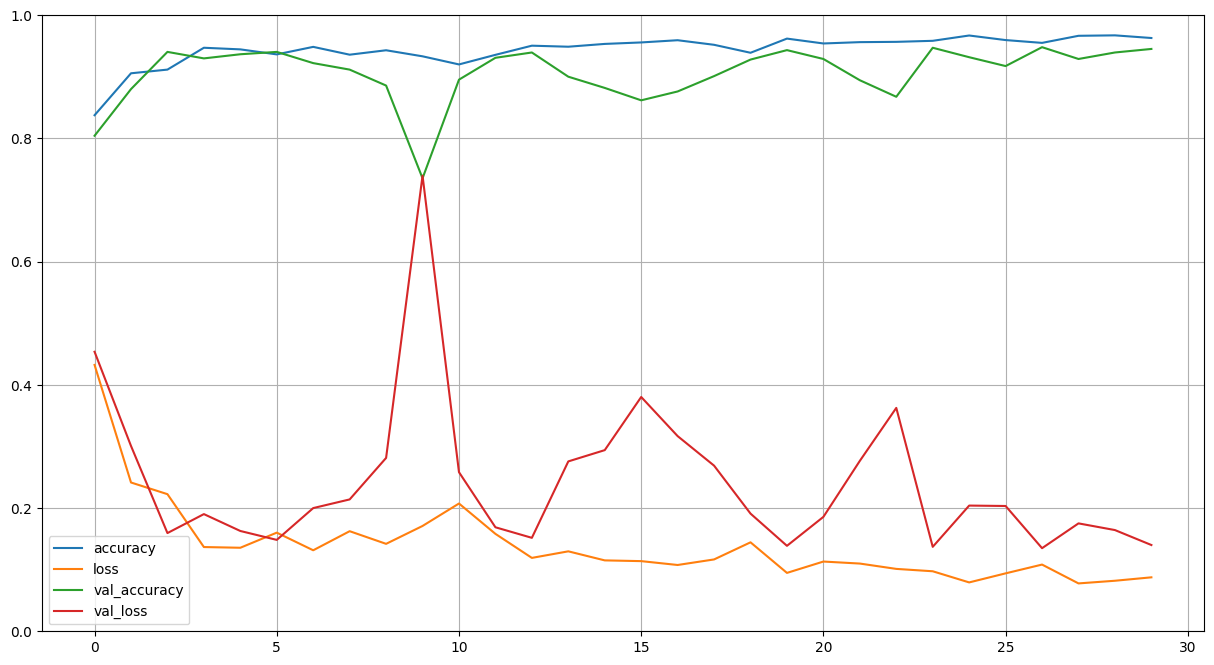

In [ ]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

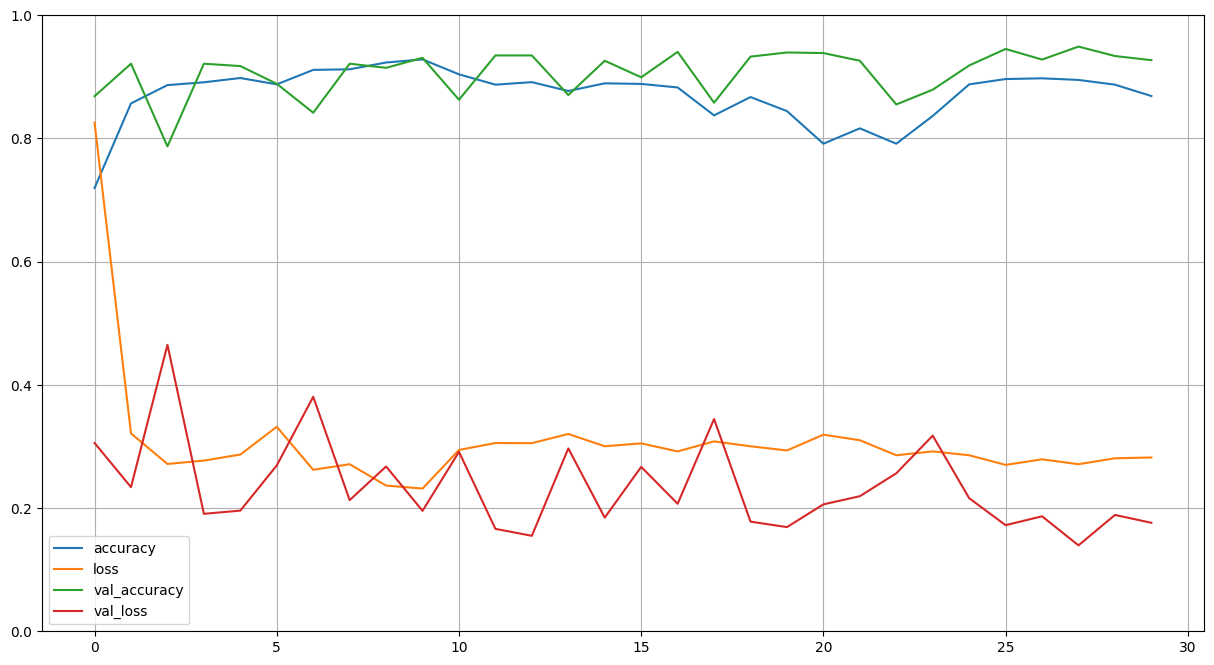

In [ ]:
# after dropout
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

**Note**
- Signs of underfitting this time around, let us bring the drop out rate down a notch

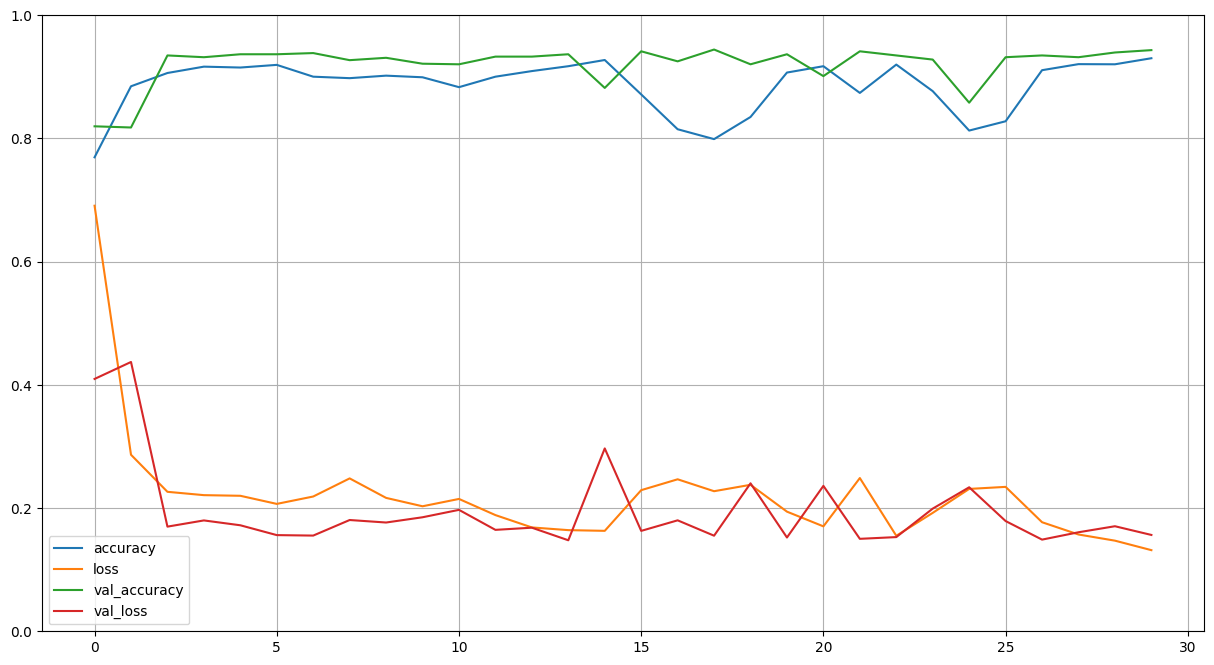

In [ ]:
# after 20% drop out (not underfitting really)
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

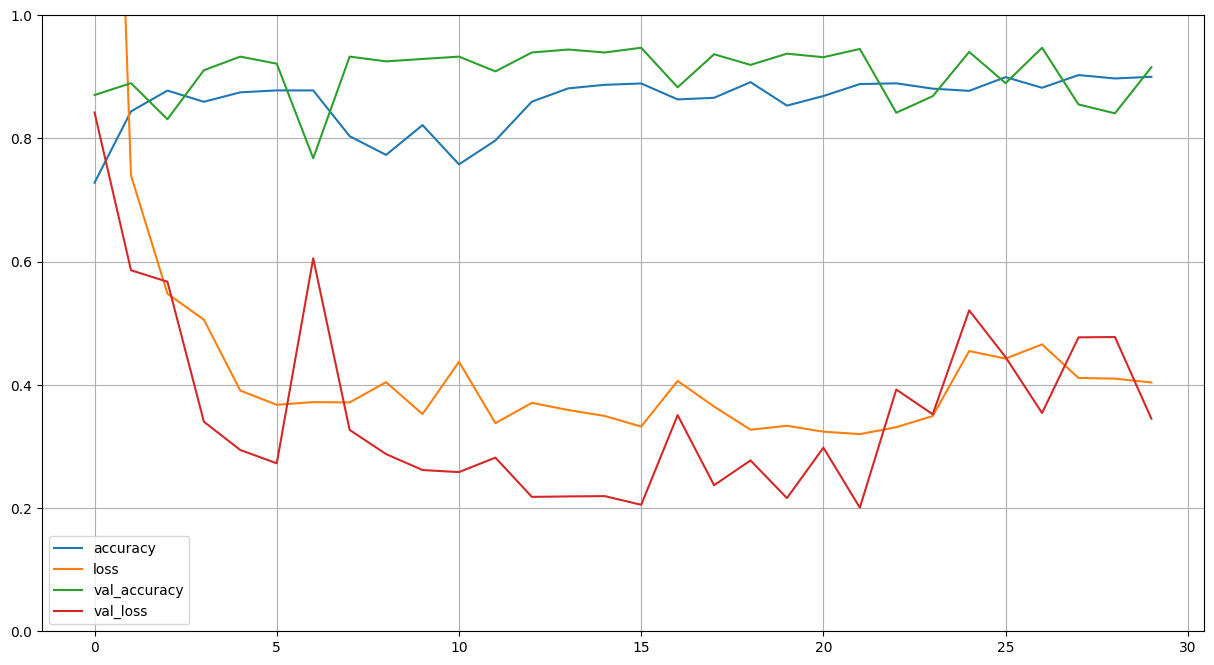

In [ ]:
# graph after l2 reg
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

**Notes**
to be fair, we did not choose the alpha value, but since our 20% frop out model was good enough, based on the graph, we should keep that

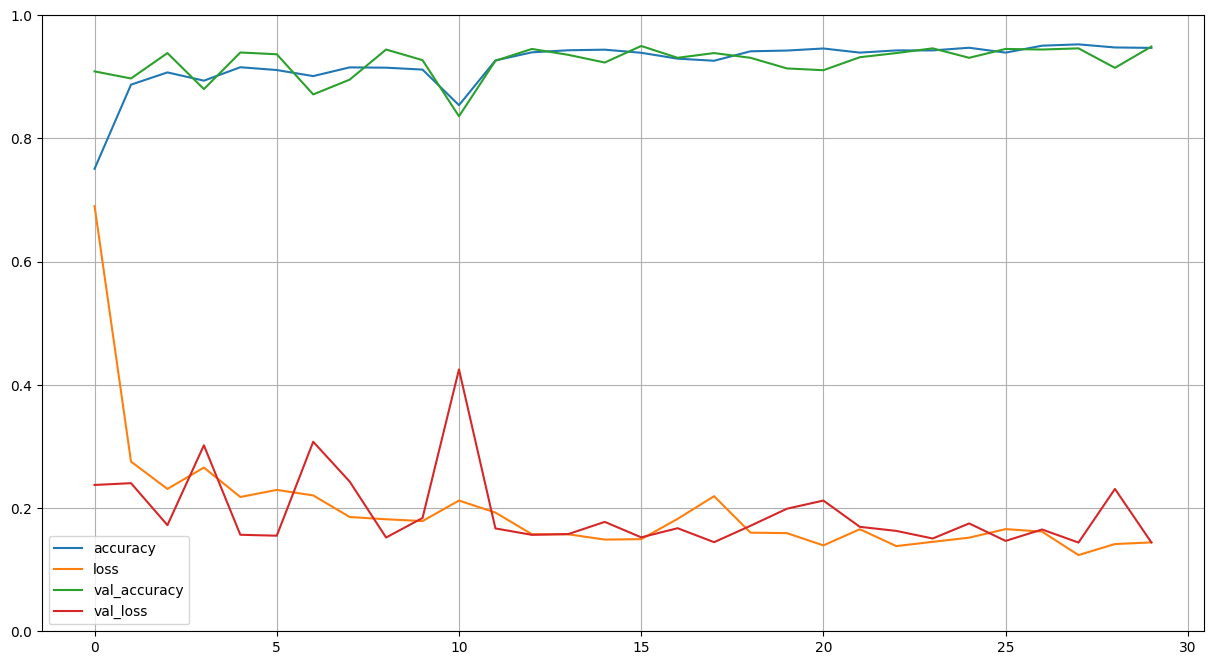

In [ ]:
# checking if the 20% dropout model is still solid
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 242ms/step


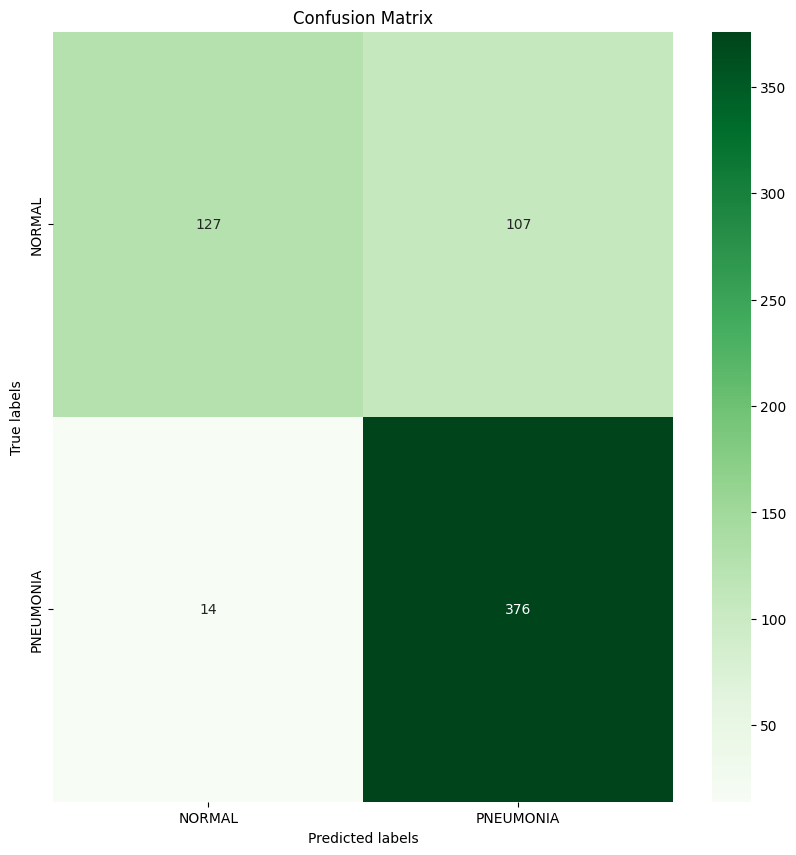

In [ ]:
# confusion matrix
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1 - get predictions from the model
predictions = model.predict(test_generator)

# 2 - convert probabilities to class labels (0 or 1)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# 3 - get the true labels from the generator
true_classes = test_generator.classes

# 4 - class names in the right order
class_names = ['NORMAL', 'PNEUMONIA']  # 0=NORMAL, 1=PNEUMONIA

# 5 - compute the matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 6 - plot it
plt.figure(figsize=(6, 4))
fig = sb.heatmap(cm, annot=True, fmt='g', cmap='Greens')

fig.set_xlabel('Predicted labels')
fig.set_ylabel('True labels')
fig.set_title('Confusion Matrix')
fig.xaxis.set_ticklabels(class_names)
fig.yaxis.set_ticklabels(class_names)
fig.figure.set_size_inches(10, 10)

plt.show()

**NOTES**
In medics, We do not wanna to tell a sick person that he's fine

### Testing the model with external images

In [ ]:
from PIL import Image
import numpy as np

# load and preprocess your image to match our model's expected input
img = Image.open("n1.jpeg").convert("RGB")   # RGB not grayscale — our model expects 3 channels (64x64x3)
img = img.resize((64, 64))                     # resize to 64x64 — must match target_size in your generators
img_array = np.array(img) / 255.0             # normalize to [0, 1] — same as rescale=1./255 in the generator

# predict
prediction = model.predict(img_array.reshape(1, 64, 64, 3))  # shape: (1, 64, 64, 3) — the 1 is the batch dimension
probability = prediction[0][0]                                 # single value between 0 and 1

# interpret result
if probability > 0.5:
    print(f"Predicted: PNEUMONIA ({probability:.2%} confidence)")
else:
    print(f"Predicted: NORMAL ({1 - probability:.2%} confidence)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted: NORMAL (99.97% confidence)


### Model Evaluation.

In [ ]:
# classification report
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=['NORMAL', 'PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.90      0.54      0.68       234
   PNEUMONIA       0.78      0.96      0.86       390

    accuracy                           0.81       624
   macro avg       0.84      0.75      0.77       624
weighted avg       0.82      0.81      0.79       624



### Saving the ANN Model


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model.save('/content/drive/MyDrive/pneum-project/ann_v1.h5')

In [ ]:

# make sure the folder exists
import os

os.makedirs('/content/drive/MyDrive/pneum-project', exist_ok=True)

In [ ]:

# verify it was saved correctly
!ls /content/drive/MyDrive/pneum-project

ann_v1.h5
